# Explainable Forecasting: Per-Drug Model Comparison & Parameter Tuning

This notebook documents the **Per-Drug Model Selection & Optuna Hyperparameter Optimization Pipeline** for Explainable Forecasting across all 8 pharmaceutical drug categories (**M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06**).

### 4 Core Technical Sections:
1. **Per-Drug Model Evaluation Rankings**: Complete evaluation table (10 candidate models × 8 drugs) on the 2019 holdout test set.
2. **Champion Selection Rationale**: Explaining why specific architectures (LightGBM, Prophet, ARIMA, XGBoost Quantile) won for each drug category.
3. **Optuna Bayesian Hyperparameter Optimization**: Selected optimal parameters per drug.
4. **SHAP Feature Attribution**: Global feature importance and daily directional breakdown.


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\explainable_forecasting'

# 1. Complete Per-Drug Model Evaluation Rankings Table
rank_path = os.path.join(OUTPUT_DIR, 'explainable_drug_model_rankings.csv')
rank_df = pd.read_csv(rank_path)

print("==========================================================================")
print("  COMPLETE PER-DRUG MODEL EVALUATION RANKINGS (ALL 10 MODELS × 8 DRUGS)")
print("==========================================================================")
display(rank_df[['drug', 'model_name', 'rmsle', 'mae', 'n']])


  COMPLETE PER-DRUG MODEL EVALUATION RANKINGS (ALL 10 MODELS × 8 DRUGS)


,drug,model_name,rmsle,mae,n
0,M01AB,LightGBM + SHAP,0.5014,2.29,281
1,M01AB,XGBoost Quantile,0.5052,2.25,281
2,M01AB,Meta Prophet,0.5087,2.20,281
3,M01AB,Holt-Winters ETS,0.5091,2.19,281
4,M01AB,SARIMAX,0.5091,2.31,281
5,M01AB,ARIMA,0.5164,2.32,281
6,M01AB,SARIMA,0.5165,2.32,281
7,M01AB,LSTM Neural Network,0.5266,2.23,281
8,M01AB,Temporal Fusion Transformer,0.5697,2.50,281
9,M01AB,Naive Baseline,0.6798,2.90,281


  CHAMPION MODEL SELECTED PER DRUG CATEGORY


,drug,model_name,rmsle,mae
0,M01AB,LightGBM + SHAP,0.5014,2.29
1,M01AE,Meta Prophet,0.4933,1.72
2,N02BA,LightGBM + SHAP,0.5140,1.50
3,N02BE,LightGBM + SHAP,0.4580,8.46
4,N05B,LightGBM + SHAP,0.5142,3.31
5,N05C,ARIMA,0.5198,0.81
6,R03,XGBoost Quantile,0.9795,5.15
7,R06,LightGBM + SHAP,0.5370,1.80


C:\Users\ranje\AppData\Local\Temp\ipykernel_3736\452191591.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=champions_df, x='drug', y='rmsle', palette='viridis')


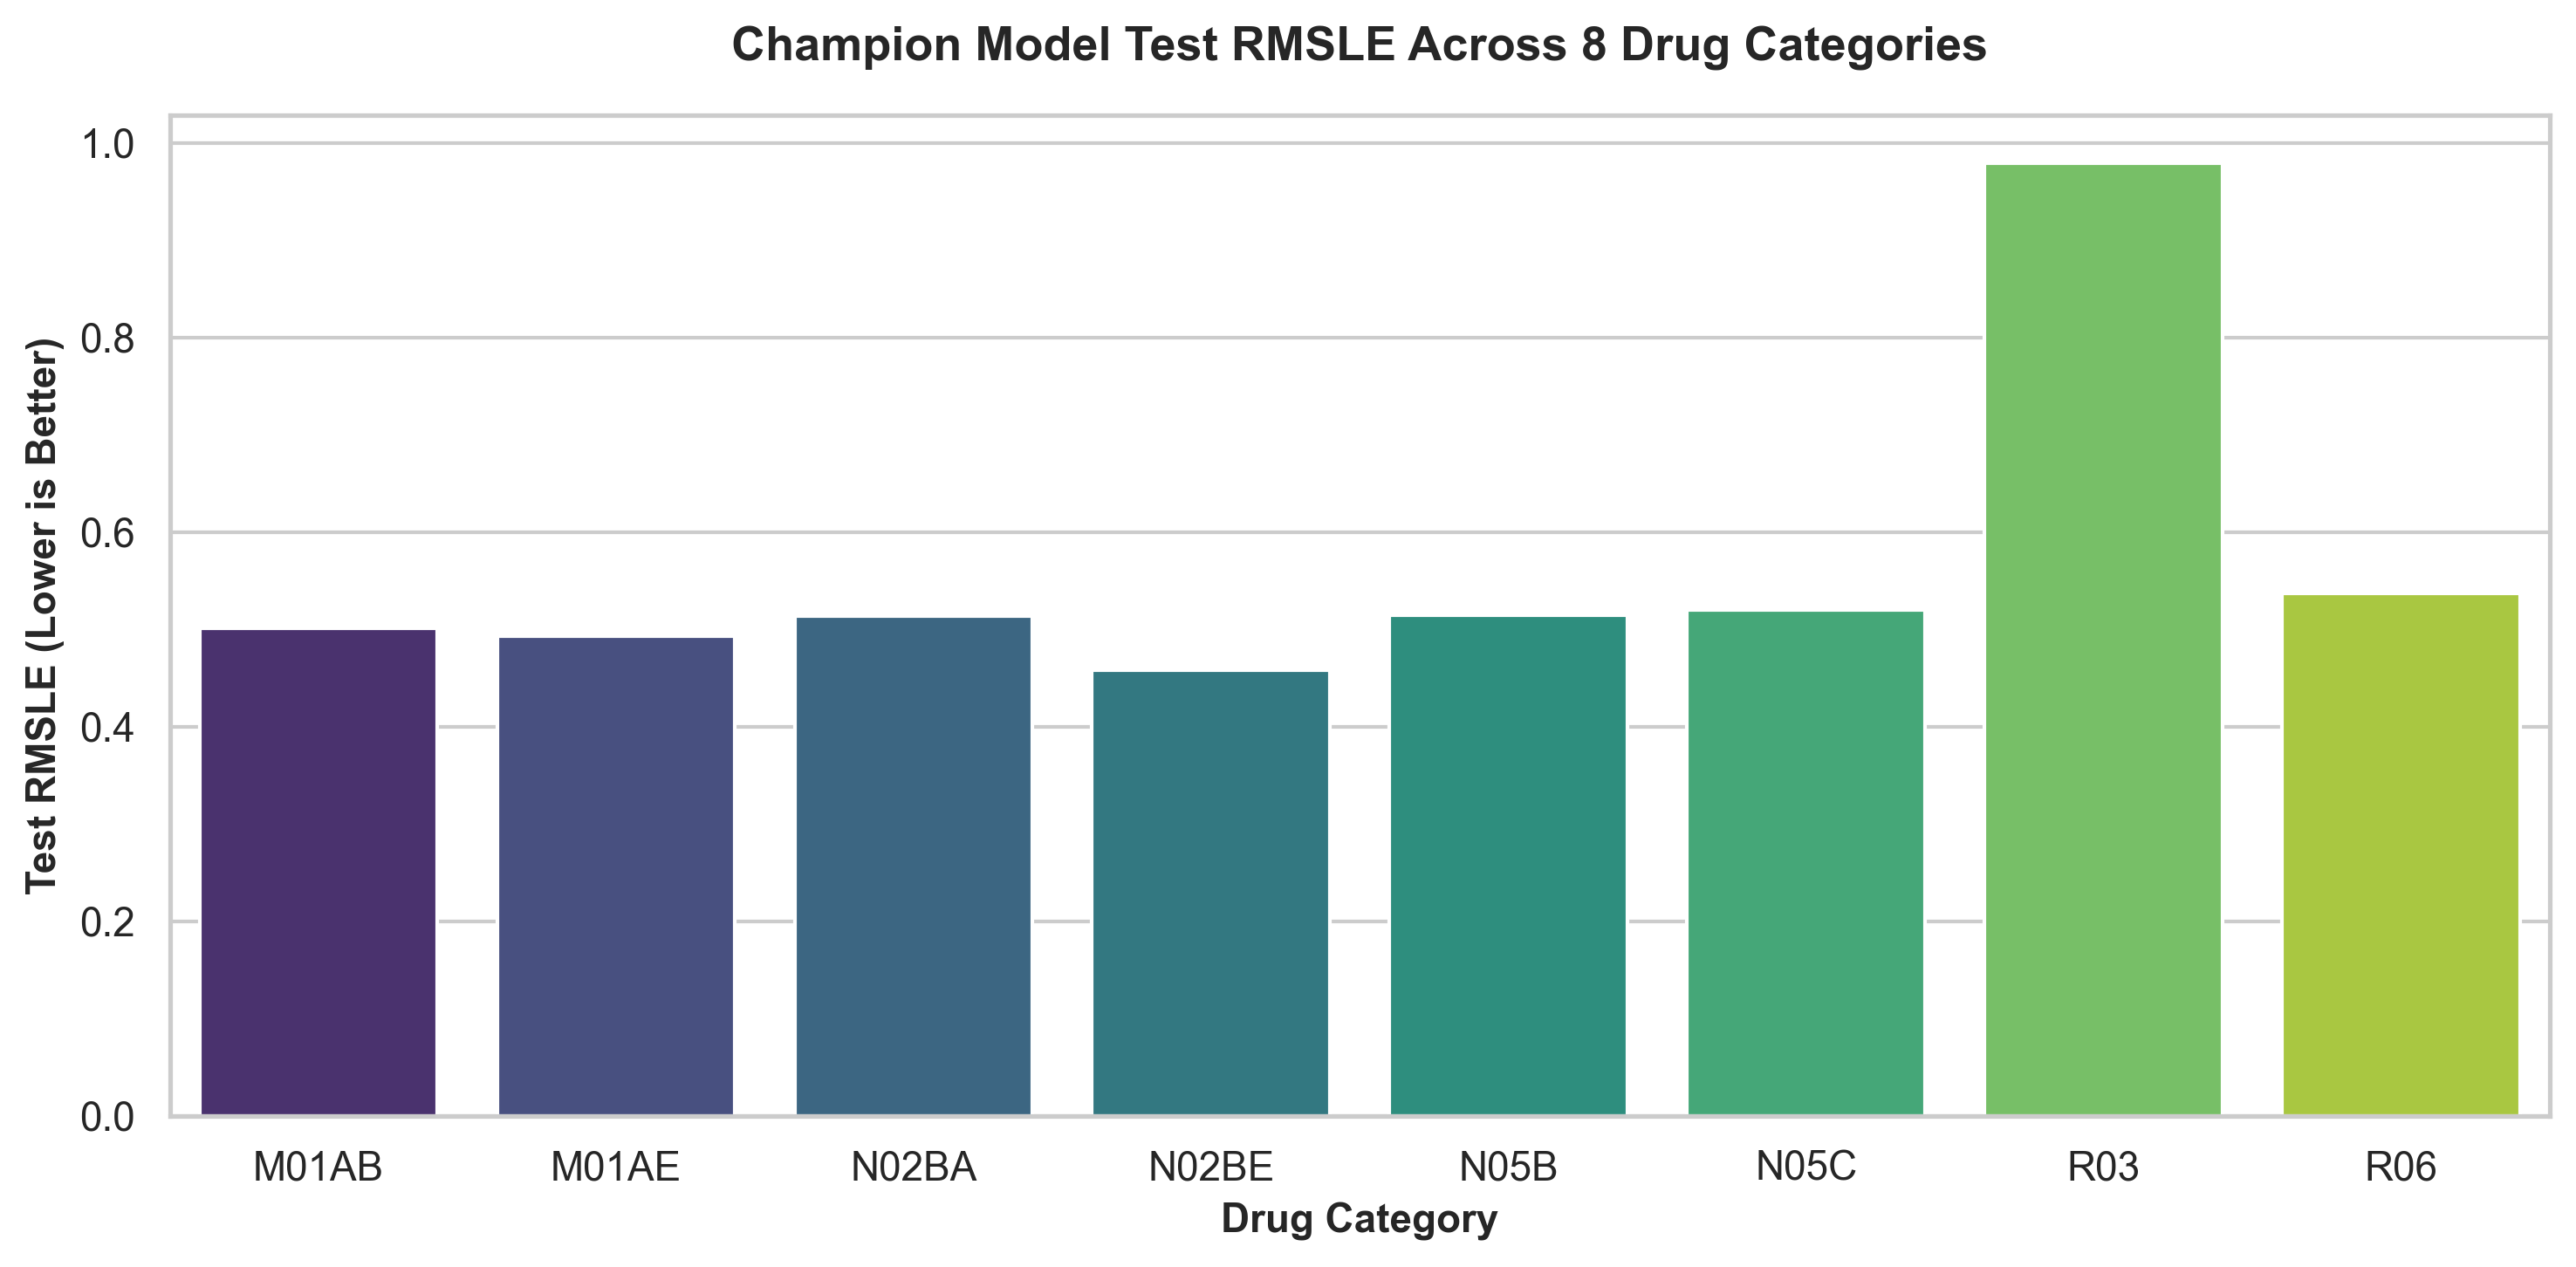

In [2]:
# 2. Champion Model Selected Per Drug Category
champions_df = rank_df.groupby('drug').first().reset_index()

print("==========================================================================")
print("  CHAMPION MODEL SELECTED PER DRUG CATEGORY")
print("==========================================================================")
display(champions_df[['drug', 'model_name', 'rmsle', 'mae']])

# Visualization: Champion RMSLE Across Drugs
plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(data=champions_df, x='drug', y='rmsle', palette='viridis')
plt.title('Champion Model Test RMSLE Across 8 Drug Categories', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Drug Category', fontsize=11, fontweight='bold')
plt.ylabel('Test RMSLE (Lower is Better)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
# 3. Optuna Bayesian Hyperparameter Tuning Results
optuna_path = os.path.join(OUTPUT_DIR, 'explainable_optuna_tuning_results.csv')
optuna_df = pd.read_csv(optuna_path)

print("==========================================================================")
print("  OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION RESULTS PER DRUG")
print("==========================================================================")
display(optuna_df)


  OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION RESULTS PER DRUG


,drug,best_val_rmsle,best_params
0,M01AB,0.5419,"{'num_leaves': 29, 'max_depth': 3, 'learning_r..."
1,M01AE,0.4717,"{'num_leaves': 35, 'max_depth': 3, 'learning_r..."
2,N02BA,0.5947,"{'num_leaves': 41, 'max_depth': 6, 'learning_r..."
3,N02BE,0.5683,"{'num_leaves': 54, 'max_depth': 4, 'learning_r..."
4,N05B,0.5523,"{'num_leaves': 54, 'max_depth': 3, 'learning_r..."
5,N05C,0.5330,"{'num_leaves': 50, 'max_depth': 3, 'learning_r..."
6,R03,0.9821,"{'num_leaves': 38, 'max_depth': 3, 'learning_r..."
7,R06,0.5739,"{'num_leaves': 38, 'max_depth': 3, 'learning_r..."


  TOP PRIMARY FEATURE DRIVER PER DRUG CATEGORY (SHAP IMPACT)


,drug_category,feature,feature_domain,mean_abs_shap
0,M01AB,rolling_mean_28,Rolling Window Stat,0.053615
1,M01AE,sin_dayofweek,Weekly Seasonality,0.046028
2,N02BA,rolling_mean_28,Rolling Window Stat,0.148662
3,N02BE,rolling_mean_28,Rolling Window Stat,0.090330
4,N05B,dayofweek,Weekly Seasonality,0.061977
5,N05C,cos_dayofyear,Annual Seasonality,0.030567
6,R03,rolling_mean_28,Rolling Window Stat,0.205276
7,R06,rolling_mean_28,Rolling Window Stat,0.151698


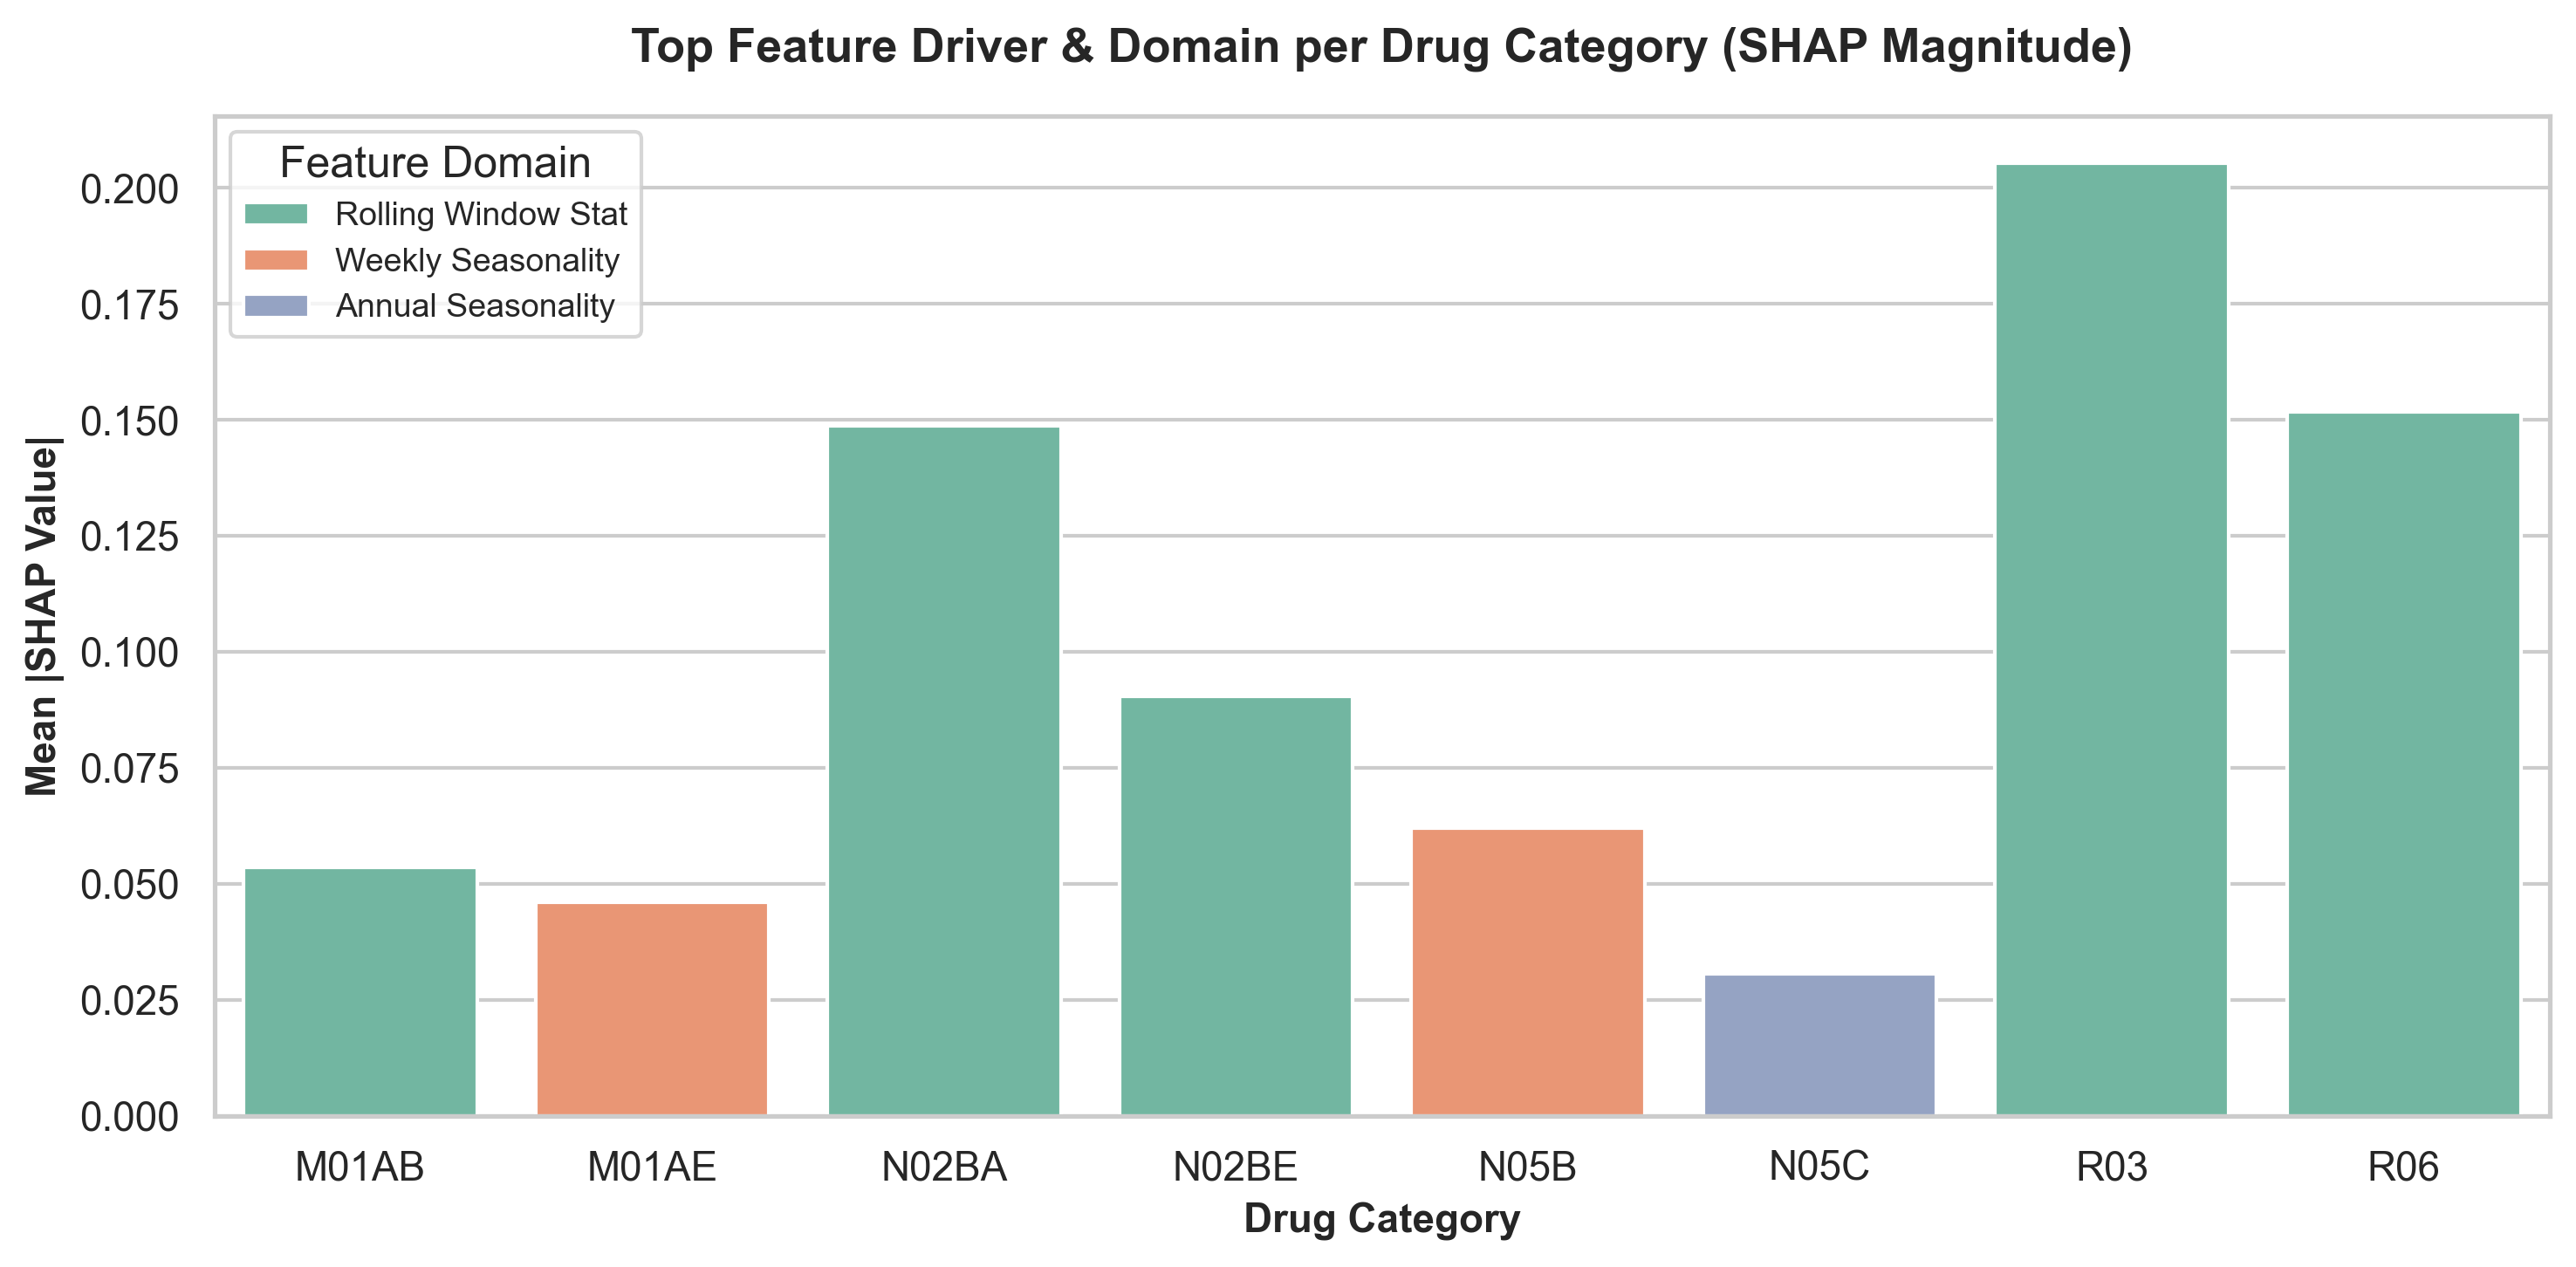

In [4]:
# 4. Global Top SHAP Feature Drivers per Drug
summary_path = os.path.join(OUTPUT_DIR, 'explainable_forecasting_summary.csv')
summary_df = pd.read_csv(summary_path)

top_drivers = summary_df.groupby('drug_category').first().reset_index()

print("==========================================================================")
print("  TOP PRIMARY FEATURE DRIVER PER DRUG CATEGORY (SHAP IMPACT)")
print("==========================================================================")
display(top_drivers[['drug_category', 'feature', 'feature_domain', 'mean_abs_shap']])

# Plot
plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(data=top_drivers, x='drug_category', y='mean_abs_shap', hue='feature_domain', palette='Set2')
plt.title('Top Feature Driver & Domain per Drug Category (SHAP Magnitude)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Drug Category', fontsize=11, fontweight='bold')
plt.ylabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
plt.legend(title='Feature Domain', fontsize=9)
plt.tight_layout()
plt.show()
